# Plot TF-target overlap

Load one subcellular CSV file from terminal input and draw an overlaid scatter plot for one TF gene and one regulated gene.

Expected CSV columns: `gene`, `x`, `y`.

In [32]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [33]:
csv_path = Path(r"F:\st\SVGRN_subcellular\in_sim\g110_c2k_n01\r05_data\cell1_subcellular.csv")
tf_gene = "10"
target_gene = "22"

In [34]:
if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found: {csv_path}")

sub_df = pd.read_csv(csv_path)
required_cols = {"gene", "x", "y"}
missing_cols = required_cols.difference(sub_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

sub_df = sub_df.copy()
sub_df["gene"] = sub_df["gene"].astype(str)
tf_gene = str(tf_gene)
target_gene = str(target_gene)

tf_df = sub_df[sub_df["gene"] == tf_gene]
target_df = sub_df[sub_df["gene"] == target_gene]

if tf_df.empty:
    raise ValueError(f"TF gene not found in CSV: {tf_gene}")
if target_df.empty:
    raise ValueError(f"Regulated gene not found in CSV: {target_gene}")

print(f"Loaded: {csv_path}")
print(f"TF points: {len(tf_df)}")
print(f"Target points: {len(target_df)}")

Loaded: F:\st\SVGRN_subcellular\in_sim\g110_c2k_n01\r05_data\cell1_subcellular.csv
TF points: 98
Target points: 84


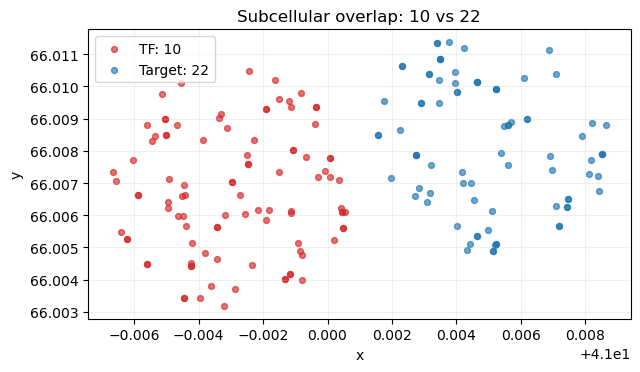

In [35]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    tf_df["x"],
    tf_df["y"],
    s=18,
    alpha=0.65,
    c="#d62728",
    label=f"TF: {tf_gene}",
)
ax.scatter(
    target_df["x"],
    target_df["y"],
    s=18,
    alpha=0.65,
    c="#1f77b4",
    label=f"Target: {target_gene}",
)

ax.set_title(f"Subcellular overlap: {tf_gene} vs {target_gene}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.2)
plt.show()